In [1]:
import lsdb
from astropy.timeseries import LombScargle
from nested_pandas.utils import count_nested
from dask.distributed import Client

# LSDB on RSP: ~100 DP2 RR Lyrae Periods

Using LSDB to calculate periods for ~100 known RR Lyrae Stars from DP2 lightcurves. The challenge here is to get this to work on the RSP with it's limited resource allocation.

Some larger takeaways:
*  **<span style="color:green">Good:</span>** Using Sean's experimental branch, memory consumption is incredibly stable, I was seeing at most 7GBs of usage in my workflows (that worked) and never encountered an out of memory error outside of ambitious computes()
*  **<span style="color:green">Good:</span>** Saving intermediate steps to disk, and search filters are fairly reliable ways to get out of a lot of the failure modes
*  **<span style="color:red">Needs Work:</span>** LSDB Main will really just not work on the RSP, due to large task graphs. Sean's branch makes it possible, but has other limitations
*  **<span style="color:red">Needs Work:</span>** We want Dask to be able to optimize our task graphs to avoid full graph computes when only looking at a subset of data, there's a good number of operations that seem to make our graphs "opaque", turning off this ability. Note that LSDB main doesn't suffer from this as much (if at all) due to the delayed implementation, but see issue above:
    * `query()` potentially
    * `head()` potentially
*  **<span style="color:red">Needs Work:</span>** Catalogs that have been loaded and heavily filtered/queried have real usability issues:
    *  the partitioning doesn't change so there are many small and even empty partitions hanging around, making further work have way too much dask overhead compared to the actual amount of data being processed.
    *  Operations like `prune_empty_partitions` exist, but land squarely in the realm of operations that will fail because of this dask overhead, so are effectively unusable
    *  data peeking operations lose a lot of ability (LSDB `head()`, which tries to grab the first n from all partitions, trawls way too much of the graph, Dask `head()`, which just looks at the first partition, will probably just show an empty partition)
*  **<span style="color:red">Needs Work:</span>** Related to above, crossmatches that have dramatically different orders introduce a lot of graph pressure due to the amount of matches and rereads


## Setup


> **<span style="color:red">Rough Edge:</span>** LSDB main will struggle heavily with the resource limitations of RSP, due to large task graphs from `to_delayed()`/`from_delayed()` loops. This notebook switches to Sean's experimental branch that swaps that loop out for a `map_partitions` call in crossmatching

In [3]:
#cd /home/b/brantd/lsdb
# pip install -e . # switch to sean/map_parts_align for map_partitions implementation of crossmatch

In [4]:
lsdb.__version__

'0.8.3.dev4+g2f9c47079'

> **<span style="color:red">Rough Edge:</span>** Using a distributed client is really important for graph/filtering execution, at least in this branch

> **<span style="color:red">Rough Edge:</span>** RSP tmp space running out was the new "out of memory" error for this workflow, can't get around it either so have to make efficient graphs to not have the dask-scratch-space balloon too big

> **<span style="color:green">Something Cool:</span>** The following workflow fits comfortably in this memory setup, well within RSP limitations

In [ ]:
client = Client(n_workers=4, threads_per_worker=1, memory_limit="6GB") # Using a distributed client is really important for pushing task layers

# technically would be cheating, but can't set an offshore tmp
#import dask
#dask.config.set({'temporary_directory': '/sdf/home/b/brantd/tmp'})

## Load VSX and Filter for RR Lyrae Stars -- Write out to Local Catalog

First step is to load VSX from a hats-on-the-fly version and query for known RR Lyrae.

> **<span style="color:red">Rough Edge:</span>** VSX hats-on-the-fly has an issue where the index is dropped, which potentially was causing crossmatches to fail with "no catalog overlap" errors, maybe, it also could be sparse partitions which is called out further below

Due to the above, needed to effectively re-import it by computing the query result, loading through `from_dataframe` and then writing it out to a catalog.

> **<span style="color:red">Rough Edge:</span>** Because I did this using defaults, the pixels are massive (spatially) compared to DP2 which likely causes a bunch of downstream rough edges/rakes related to large graphs

In [78]:
# Load remote, query, and write a local RR Lyrae Catalog
vsx = lsdb.open_catalog("https://vizcat.cds.unistra.fr/hats/B/vsx/vsx/") # maybe need to store locally
vsx = vsx.query("Type == 'RR' or Type == 'RRAB' or Type == 'RRC' or Type=='RRD'")


# VSX is messed up, reimport from dataframe and write
#vsx_df = vsx.compute()
#lsdb.from_dataframe(vsx_df, ra_column="_RAJ2000", dec_column="_DEJ2000").write_catalog("vsx_rrlyr", overwrite=True)

#vsx.write_catalog("vsx_rrlyr", overwrite=True)


In [5]:
# Tried this to infer types, but took a long time and probably just consult VSX docs for correct type labels
# Wacky idea, but it would be cool to have certain categorical columns have metadata associated with possible values
#vsx["Type"].unique().compute()

## Load DP2, VSX RRLyrae, and Crossmatch

Next, we can load DP2, our VSX RRLyrae cut, and crossmatch them together:

> **<span style="color:red">Rough Edge:</span>** The full crossmatch yields ~20000 partitions for only ~300,000 RR Lyrae on the VSX side, these output partitions are extremely sparse. Which has a bunch of usability issues:
> + `xmatch.compute()` will fail because of the size of the graph/size of local available tmp space
> + `xmatch.head(100)` I think this will try to compute the full task graph first, or maybe just a lot of it since the partitions are very very sparse, leading to the same issues as above
> + `xmatch.partitions[0].head(10)` is a way to avoid full graph computation, but if the partitions are sparse these will probably be empty
> + `xmatch.partitions[0:5].head(10)` doesn't work on lsdb for some reason, but we can through dask directly `xmatch._ddf.partitions[0:5].head(10)`

> **<span style="color:red">Rough Edge:</span>** Because I can't really work with the full crossmatch, I needed to find the overlap region by eye and do some box_searches. And I further needed to find regions that actually had enough observations for time-domain work

> **<span style="color:green">Something Cool:</span>** plot_pixels is great though

In [49]:
# Loading and crossmatching
#bsearch = lsdb.BoxSearch(ra=(0,360), dec=(-90,90))
# This region doesn't have enough data in the lightcurves
#bsearch = lsdb.BoxSearch(ra=(250,295), dec=(-30,0)) #~7000 partitions
#bsearch = lsdb.BoxSearch(ra=(276,284), dec=(-30,0)) #~250 partitions, working
#bsearch = lsdb.BoxSearch(ra=(274,286), dec=(-30,0)) #~1800 partitions, working

# Has some larger lightcurves
bsearch=lsdb.BoxSearch(ra=(0,180), dec=(-90,15)), #~3800 partitions, working
#bsearch=lsdb.BoxSearch(ra=(0,180), dec=(-90,-30)), #~1700 partitions, working
dp2 = lsdb.open_catalog('/sdf/data/rubin/shared/lsdb_commissioning/hats/v30_0_0_rc2/object_collection',
                        search_filter=bsearch)
vsx_rrl = lsdb.open_catalog('vsx_rrlyr',search_filter=bsearch)

xmatch = dp2.crossmatch(vsx_rrl, suffix_method='overlapping_columns')

/home/b/brantd/.local/lib/python3.12/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


,coord_dec,coord_decErr,coord_ra,coord_raErr,g_psfFlux,g_psfFluxErr,g_psfMag,g_psfMagErr,i_psfFlux,i_psfFluxErr,i_psfMag,i_psfMagErr,objectId,patch,r_psfFlux,r_psfFluxErr,r_psfMag,r_psfMagErr,refBand,shape_flag,shape_xx,shape_xy,shape_yy,tract,u_psfFlux,u_psfFluxErr,u_psfMag,u_psfMagErr,y_psfFlux,y_psfFluxErr,y_psfMag,y_psfMagErr,z_psfFlux,z_psfFluxErr,z_psfMag,z_psfMagErr,objectForcedSource
npartitions=3789,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 9, Pixel: 1130863",double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],"nested<band: [string], coord_dec: [double], co..."
"Order: 7, Pixel: 70679",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 8, Pixel: 578144",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 6, Pixel: 36136",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


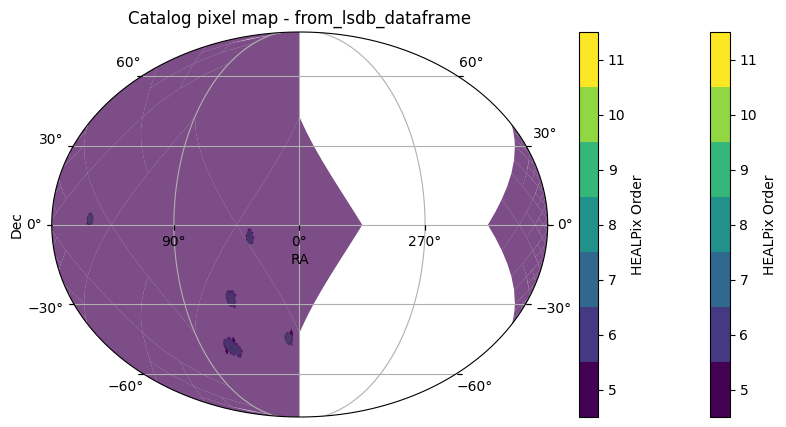

In [50]:
dp2.plot_pixels()
vsx_rrl.plot_pixels(alpha=0.7)
dp2

> **<span style="color:red">Rough Edge:</span>** Save the results to disk, because it takes kind of awhile. Maybe not quite a rough edge, but could trip someone up

In [55]:
# Save results to disk
xmatch_df = xmatch.compute()
xmatch_df.to_parquet("matched_rrls.parquet")

## Pre-Filtering, select first 100 RR Lyrae

At this point, we only get 80 surviving RR Lyrae, so just work in memory.

In [82]:
import nested_pandas as npd
xmatch_df = npd.read_parquet("matched_rrls.parquet")
#xmatch_df

In [80]:
# Pre-Filtering
xmatch_g = xmatch_df.query("objectForcedSource.band == 'g'") # single band

# maybe need count_nested if n_obs_g isn't available
xmatch_g = count_nested(xmatch_g, nested="objectForcedSource", join=True)

xmatch_g = xmatch_g.query("n_objectForcedSource > 20") # choose a good threshold

> **<span style="color:red">Rough Edge:</span>** I wish this was easier to see subcolumns of a nested column

In [62]:
xmatch_g.get_subcolumns("objectForcedSource")

['objectForcedSource.band',
 'objectForcedSource.coord_dec',
 'objectForcedSource.coord_ra',
 'objectForcedSource.detector',
 'objectForcedSource.invalidPsfFlag',
 'objectForcedSource.midpointMjdTai',
 'objectForcedSource.pixelFlags_bad',
 'objectForcedSource.pixelFlags_cr',
 'objectForcedSource.pixelFlags_crCenter',
 'objectForcedSource.pixelFlags_edge',
 'objectForcedSource.pixelFlags_interpolated',
 'objectForcedSource.pixelFlags_interpolatedCenter',
 'objectForcedSource.pixelFlags_nodata',
 'objectForcedSource.pixelFlags_saturated',
 'objectForcedSource.pixelFlags_saturatedCenter',
 'objectForcedSource.pixelFlags_suspect',
 'objectForcedSource.pixelFlags_suspectCenter',
 'objectForcedSource.psfDiffFlux',
 'objectForcedSource.psfDiffFlux_flag',
 'objectForcedSource.psfDiffFluxErr',
 'objectForcedSource.psfFlux',
 'objectForcedSource.psfFlux_flag',
 'objectForcedSource.psfFluxErr',
 'objectForcedSource.psfMag',
 'objectForcedSource.psfMagErr',
 'objectForcedSource.visit']

## Run LombScargle

In [76]:
# Period Calculation
from astropy.timeseries import LombScargle
import numpy as np

def calc_period(row):
    t = row["objectForcedSource.midpointMjdTai"]
    y = row["objectForcedSource.psfFlux"]
    dy = row["objectForcedSource.psfFluxErr"]
    frequency = np.linspace(0.1, 3.0, 1000)  # cheating
    power = LombScargle(t, y, dy).power(frequency)
    period = 1/frequency[np.argmax(power)]
    return period

result = xmatch_g.map_rows(calc_period, output_names="period_LS")
result = xmatch_g.join(result)
result[["Period", "period_LS"]]

,Period,period_LS
12,0.503362,0.489011
13,0.637809,0.604941
...,...,...
78,0.58213,0.664450
79,0.481198,0.399424


# Discarded Iterations: Rakes Ahead

> **<span style="color:red">Rough Edge:</span>** Head does full(?) compute, no space left on disk

In [ ]:
#xmatch.head(100)
#xmatch._ddf.head(100, npartitions=-1)

> **<span style="color:red">Rough Edge:</span>** At various points tried a write_catalog instead of a compute, which ran into kernel crashes, and resume did not seem to work

In [4]:
#xmatch.write_catalog("dp2_rrl", resume=True)

> **<span style="color:red">Rough Edge:</span>** It would have been awesome if this worked, I had a lot of empty partitions to prune, but it's expensive and fails just like a compute, no space left on disk

In [5]:
# No space on disk
#xmatch_pruned = xmatch.prune_empty_partitions()
#xmatch_pruned

> **<span style="color:red">Rough Edge:</span>** I tried for awhile to avoid the boxsearch, and wanted to just crawl the partitions for any signs of data. Was a good opportunity to try the new CatalogStream, but it was executing the full graph before each partition so something was wrong/needs to improve there

In [26]:
from lsdb.streams import CatalogStream
import pandas as pd
rrl_stream = CatalogStream(xmatch, shuffle=False)
for i,chunk in enumerate(rrl_stream):
    if i==0:
        rrl_df = chunk
    else:
        pd.concat([rrl_df, chunk])
    if len(rrl_df) >= 100:
        break
rrl_df

> **<span style="color:red">Rough Edge:</span>** Given above, shifted to a more manual partition crawling approach (ejecting to pure dask dataframes). I think this would work, but is very slow and might require this insane `Client.restart()` call to clear tmp occasionally

In [ ]:
from lsdb.streams import CatalogStream
import pandas as pd
#rrl_stream = CatalogStream(xmatch, shuffle=False)
for i,chunk in enumerate(xmatch._ddf.partitions):
    #if i<100:
    #    continue
    #if i>200:
    #    break
    if i%%5 == 0:
        Client.restart()
    chunk = chunk.compute()
    if i==0:
        rrl_df = chunk
    else:
        pd.concat([rrl_df, chunk], ignore_index=True)
    if len(rrl_df) >= 100:
        break
rrl_df

> **<span style="color:red">Rough Edge:</span>** Before opting to just work in nested-pandas, I tried to do some of the filtering work lazily, but it just exacerbates the many partitions->no data issue further.

In [81]:
# Pre-Filtering
xmatch = xmatch.query("objectForcedSource.band == 'g'") # single band

# maybe need count_nested if n_obs_g isn't available
xmatch = xmatch.map_partitions(lambda df: count_nested(df, nested="objectForcedSource"))

xmatch = xmatch.query("n_objectForcedSource > 50") # choose a good threshold